---
numbering: false
---

# 1.6: Orthogonality and the Dot Product

We now know how to find the length of a vector and the distance between two points. Next, we'd like to measure the **angle between two vectors**. In particular, how can we tell whether two vectors are perpendicular without relying on a picture?

The tool we'll use is the **dot product**. It connects a simple calculation with the geometry of lengths and angles.

## Computing a dot product

:::{note} Definition: Dot product
For two vectors with the same number of components,

$$\vec u=\begin{bmatrix}u_1\\u_2\\\vdots\\u_n\end{bmatrix},\qquad
\vec v=\begin{bmatrix}v_1\\v_2\\\vdots\\v_n\end{bmatrix},$$

their **dot product** is the scalar

$$\boxed{\vec u\cdot\vec v=u_1v_1+u_2v_2+\cdots+u_nv_n.}$$
:::

Multiply corresponding components, then add the products. For example, if

$$\vec u=\begin{bmatrix}2\\1\end{bmatrix},\qquad
\vec v=\begin{bmatrix}1\\3\end{bmatrix},$$

then

$$\vec u\cdot\vec v=2(1)+1(3)=\boxed{5}.$$

The result is **one number**, not another vector. We'll call this the **computational formula**, since it tells us how to calculate a dot product from the components.

::::{tip} Activity 1
Let $\vec x=\begin{bmatrix}5\\3\\-1\end{bmatrix}$, $\vec y=\begin{bmatrix}2\\-1\\4\end{bmatrix}$, and $\vec 1=\begin{bmatrix}1\\1\\1\end{bmatrix}$.

1. Find $\vec x\cdot\vec y$.
2. Find $\vec x\cdot\vec 1$. What does taking the dot product with a vector of all 1s do?
3. Find $\vec x\cdot\vec x$ and $\lVert\vec x\rVert^2$. What do you notice?

:::{tip} Solution
:class: dropdown

1. $\vec x\cdot\vec y=5(2)+3(-1)+(-1)(4)=3$.
2. $\vec x\cdot\vec 1=5+3-1=7$. Taking the dot product with a vector of all 1s adds the components.
3. Both are $5^2+3^2+(-1)^2=35$.
:::
::::

### Basic properties

:::{note} Properties of the dot product
For vectors $\vec u,\vec v,\vec w\in\mathbb{R}^n$ and a scalar $c$:

$$\begin{aligned}
\vec u\cdot\vec v&=\vec v\cdot\vec u,\\
\vec u\cdot(\vec v+\vec w)&=\vec u\cdot\vec v+\vec u\cdot\vec w,\\
(c\vec u)\cdot\vec v&=c(\vec u\cdot\vec v)=\vec u\cdot(c\vec v).
\end{aligned}$$

Also, taking the dot product of a vector with itself gives its **squared length**:

$$\boxed{\vec v\cdot\vec v=v_1^2+\cdots+v_n^2=\lVert\vec v\rVert^2.}$$
:::

The first property says that the order doesn't matter. The second lets us distribute over addition. The third lets us pull scalars outside the dot product.

For example, if $\vec u\cdot\vec v=5$ and $\lVert\vec u\rVert=\sqrt{5}$, then

$$\begin{aligned}
\vec u\cdot(2\vec u-3\vec v)
&=2(\vec u\cdot\vec u)-3(\vec u\cdot\vec v)\\
&=2\lVert\vec u\rVert^2-3(5)\\
&=2(5)-15=-5.
\end{aligned}$$

We didn't need to know the components to do this calculation!

---

## The geometric formula

What does a dot product tell us about the vectors? Here's a second formula that connects it to their lengths and the angle between them.

:::{note} Geometric formula for the dot product
Let $\vec u$ and $\vec v$ be **nonzero** vectors. Draw them starting at the same point, and let $\theta$ be the angle between them, with $0^\circ\leq\theta\leq180^\circ$. Then

$$\boxed{\vec u\cdot\vec v=\lVert\vec u\rVert\lVert\vec v\rVert\cos\theta.}$$
:::

Both formulas give the **same number**. The computational formula uses components; the geometric formula uses lengths and an angle.

:::{attention} What you need to know
You are responsible for using both formulas for the dot product and understanding what they tell us. **You are not responsible for the proof that the two formulas are equivalent.** The optional proof is in the dropdown below.
:::

:::{note} Optional proof: Why the two formulas agree
:class: dropdown

Draw $\vec u$ and $\vec v$ from the same starting point. The distance between their tips is $\lVert\vec u-\vec v\rVert$, as we learned in Chapter 1.5. We'll compute the square of this distance in two ways.

First, the **law of cosines** says that a triangle with sides of lengths $a$ and $b$ enclosing an angle $\theta$ has opposite side length $c$ satisfying

$$c^2=a^2+b^2-2ab\cos\theta.$$

Applying this to our triangle gives

$$\lVert\vec u-\vec v\rVert^2
=\lVert\vec u\rVert^2+\lVert\vec v\rVert^2
-2\lVert\vec u\rVert\lVert\vec v\rVert\cos\theta.$$

Second, using only the computational formula and its properties,

$$\begin{aligned}
\lVert\vec u-\vec v\rVert^2
&=(\vec u-\vec v)\cdot(\vec u-\vec v)\\
&=\vec u\cdot\vec u-\vec u\cdot\vec v-\vec v\cdot\vec u+\vec v\cdot\vec v\\
&=\lVert\vec u\rVert^2+\lVert\vec v\rVert^2-2\vec u\cdot\vec v.
\end{aligned}$$

These expressions describe the same squared distance. Canceling the two squared-length terms and dividing by $-2$ gives

$$\boxed{\vec u\cdot\vec v=\lVert\vec u\rVert\lVert\vec v\rVert\cos\theta.}$$

If the vectors point along the same line, the triangle is flat. The same law-of-cosines identity still holds with $\theta=0^\circ$ or $180^\circ$.
:::

### Interpreting the sign

Since both lengths are positive, the **sign** of $\vec u\cdot\vec v$ is the sign of $\cos\theta$.

| Dot product | Angle between nonzero vectors |
| --- | --- |
| Positive | $0^\circ\leq\theta<90^\circ$: the directions are less than a right angle apart. |
| Zero | $\theta=90^\circ$: the vectors are perpendicular. |
| Negative | $90^\circ<\theta\leq180^\circ$: the directions are more than a right angle apart. |

Let's keep $\vec u=\begin{bmatrix}2\\1\end{bmatrix}$ fixed and compare it with four different vectors.

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path as _PlotPath
import sys as _plot_sys

_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly


def _vector_figure(vectors, vdeltax=0.3, vdeltay=0.3, vdeltaz=0.3):
    dimension = len(vectors[0][0][0])
    fig = go.Figure()

    for (start, end), color, label in vectors:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        delta = end - start

        if dimension == 2:
            fig.add_trace(go.Scatter(
                x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
                line=dict(color=color, width=4), showlegend=False,
                hovertemplate="(%{x}, %{y})<extra></extra>",
            ))
            fig.add_annotation(
                x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
                arrowcolor=color,
            )
            if label:
                midpoint = (start + end) / 2
                fig.add_annotation(
                    x=midpoint[0] + vdeltax, y=midpoint[1] + vdeltay,
                    text=label, showarrow=False, font=dict(color=color, size=16),
                )
        else:
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines", line=dict(color=color, width=8),
                showlegend=False, hoverinfo="skip",
            ))
            length = np.linalg.norm(delta)
            if length:
                unit = delta / length
                fig.add_trace(go.Cone(
                    x=[end[0]], y=[end[1]], z=[end[2]],
                    u=[unit[0]], v=[unit[1]], w=[unit[2]],
                    anchor="tip", sizemode="absolute", sizeref=0.28,
                    colorscale=[[0, color], [1, color]], showscale=False,
                    hoverinfo="skip",
                ))
            if label:
                midpoint = (start + end) / 2
                fig.add_trace(go.Scatter3d(
                    x=[midpoint[0] + vdeltax], y=[midpoint[1] + vdeltay],
                    z=[midpoint[2] + vdeltaz], mode="text", text=[label],
                    textfont=dict(color=color, size=16), hoverinfo="skip",
                    showlegend=False,
                ))

    return fig


def plot_vectors_non_origin(vectors, **kwargs):
    return _vector_figure(vectors, **kwargs)


def plot_vectors(vectors, **kwargs):
    converted = []
    for endpoint, color, label in vectors:
        converted.append(((tuple(0 for _ in endpoint), endpoint), color, label))
    return _vector_figure(converted, **kwargs)


def _set_vector_colors(fig, vectors, overrides):
    if np.asarray(vectors[0][0]).ndim == 1:
        vectors = [((tuple(0 for _ in endpoint), endpoint), color, label) for endpoint, color, label in vectors]
    dimension = len(vectors[0][0][0])
    trace_index = 0
    annotation_index = 0

    for vector_index, ((start, end), _, label) in enumerate(vectors):
        color = overrides.get(vector_index)
        if dimension == 2:
            if color:
                fig.data[trace_index].line.color = color
                fig.layout.annotations[annotation_index].arrowcolor = color
                if label:
                    fig.layout.annotations[annotation_index + 1].font.color = color
            trace_index += 1
            annotation_index += 1 + bool(label)
        else:
            if color:
                fig.data[trace_index].line.color = color
            trace_index += 1
            if np.linalg.norm(np.asarray(end) - np.asarray(start)):
                if color:
                    fig.data[trace_index].colorscale = [[0, color], [1, color]]
                trace_index += 1
            if label:
                if color:
                    fig.data[trace_index].textfont.color = color
                trace_index += 1

    return fig


def finish_vectors(fig, vectors, renderer="png"):
    _style_plotly(fig, renderer=renderer)
    _set_vector_colors(fig, vectors, {i: item[1] for i, item in enumerate(vectors)})
    return fig

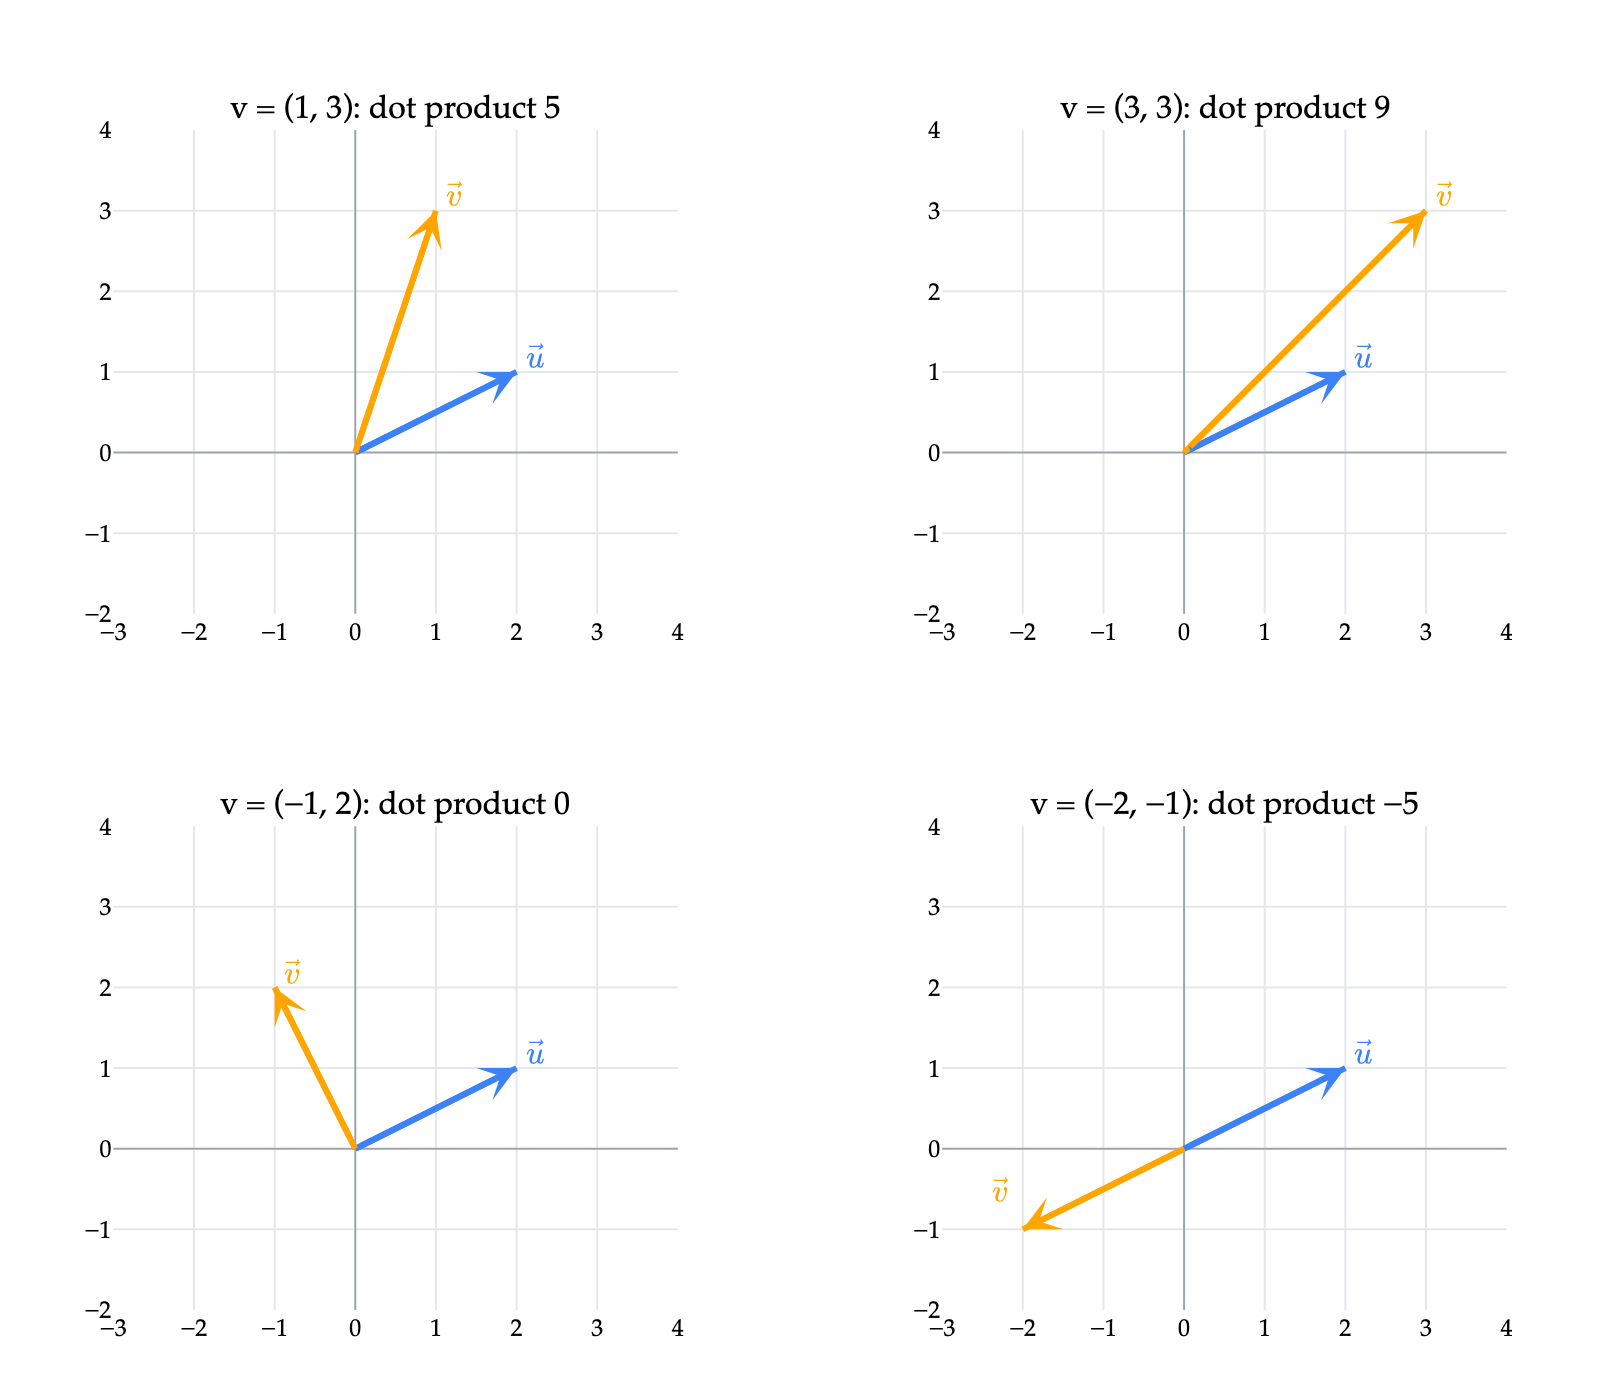

In [2]:
from plotly.subplots import make_subplots

test_vectors = [(1,3), (3,3), (-1,2), (-2,-1)]
titles = ['v = (1, 3): dot product 5', 'v = (3, 3): dot product 9',
          'v = (−1, 2): dot product 0', 'v = (−2, −1): dot product −5']
fig = make_subplots(rows=2, cols=2, subplot_titles=titles, horizontal_spacing=0.12, vertical_spacing=0.18)
_style_plotly(fig, renderer='png')
for i, endpoint in enumerate(test_vectors):
    row, col = divmod(i, 2)
    row, col = row+1, col+1
    axis_num = i+1
    xref = 'x' if axis_num == 1 else f'x{axis_num}'
    yref = 'y' if axis_num == 1 else f'y{axis_num}'
    for point, color, label in [((2,1),'#3d81f6',r'$\vec u$'),(endpoint,'orange',r'$\vec v$')]:
        fig.add_trace(go.Scatter(x=[0,point[0]],y=[0,point[1]],mode='lines',
            line=dict(color=color,width=3),showlegend=False),row=row,col=col)
        fig.add_annotation(x=point[0],y=point[1],ax=0,ay=0,xref=xref,yref=yref,
            axref=xref,ayref=yref,showarrow=True,arrowhead=3,arrowwidth=3,arrowcolor=color)
        fig.add_annotation(x=point[0]+0.25,y=point[1]+0.25,xref=xref,yref=yref,
            text=label,showarrow=False,font=dict(color=color,size=17))
    if i == 3:
        fig.layout.annotations[-1].update(x=-2.25, y=-0.45)
    fig.update_xaxes(range=[-3,4],dtick=1,constrain='domain',row=row,col=col)
    fig.update_yaxes(range=[-2,4],dtick=1,scaleanchor=xref,scaleratio=1,row=row,col=col)
fig.update_layout(width=800,height=690,margin=dict(l=35,r=25,t=65,b=35))
fig.show(scale=2)

The first two dot products are positive, the third is zero, and the fourth is negative. In the fourth picture, the vectors point in exactly opposite directions, so the angle is $180^\circ$.

Be careful when comparing the **sizes** of dot products: they depend on the lengths as well as the angle. Doubling one vector doubles the dot product without changing its direction. To isolate the angle, we'll divide by the product of the lengths.

---

## Orthogonality

**Orthogonal** is the word we use for perpendicular vectors. The geometric formula gives us an especially useful test: for nonzero vectors, the angle is $90^\circ$ exactly when the dot product is zero, because $\cos 90^\circ=0$.

:::{note} Definition: Orthogonal vectors
Two vectors $\vec u$ and $\vec v$ are **orthogonal** if

$$\boxed{\vec u\cdot\vec v=0.}$$

We write $\vec u\perp\vec v$. For nonzero vectors, this means that the angle between them is $90^\circ$.
:::

For example,

$$\begin{bmatrix}2\\1\end{bmatrix}\cdot\begin{bmatrix}-1\\2\end{bmatrix}
=2(-1)+1(2)=0,$$

so these vectors are orthogonal. This matches the third picture above.

The definition also makes $\vec 0$ orthogonal to **every** vector, since $\vec 0\cdot\vec v=0$. We do not assign an angle to the zero vector: it has no direction.

::::{tip} Activity 2
Let $\vec u=\begin{bmatrix}2\\-1\\3\end{bmatrix}$ and $\vec v=\begin{bmatrix}1\\t\\2\end{bmatrix}$.

1. Find $t$ so that $\vec u$ and $\vec v$ are orthogonal.
2. For that value of $t$, are $2\vec u$ and $-3\vec v$ also orthogonal? Explain using a dot product property.

:::{tip} Solution
:class: dropdown

1. $\vec u\cdot\vec v=2-t+6=8-t$. Setting this equal to 0 gives $t=8$.
2. Yes: $(2\vec u)\cdot(-3\vec v)=-6(\vec u\cdot\vec v)=-6(0)=0$.
:::
::::

---

## Finding the angle between vectors

For nonzero vectors, rearranging the geometric formula gives

$$\boxed{\cos\theta=\frac{\vec u\cdot\vec v}{\lVert\vec u\rVert\lVert\vec v\rVert}.}$$

Compute the dot product, compute the two lengths, and divide. Often, we'll ask for **the cosine of the angle**, so you can stop there. If we want the angle itself, take $\cos^{-1}$ of the result. Here $\cos^{-1}$ means inverse cosine, not $1/\cos$.

### Example: An angle in two dimensions

Let's keep the vectors

$$\vec u=\begin{bmatrix}2\\1\end{bmatrix},\qquad
\vec v=\begin{bmatrix}2\\6\end{bmatrix}.$$

Their dot product and lengths are

$$\vec u\cdot\vec v=2(2)+1(6)=10,\qquad
\lVert\vec u\rVert=\sqrt{5},\qquad
\lVert\vec v\rVert=\sqrt{40}.$$

Therefore,

$$\cos\theta=\frac{10}{\sqrt{5}\sqrt{40}}
=\frac{10}{10\sqrt{2}}=\boxed{\frac{1}{\sqrt{2}}}.$$

Since $\cos45^\circ=1/\sqrt{2}$, the angle is $\boxed{45^\circ}$.

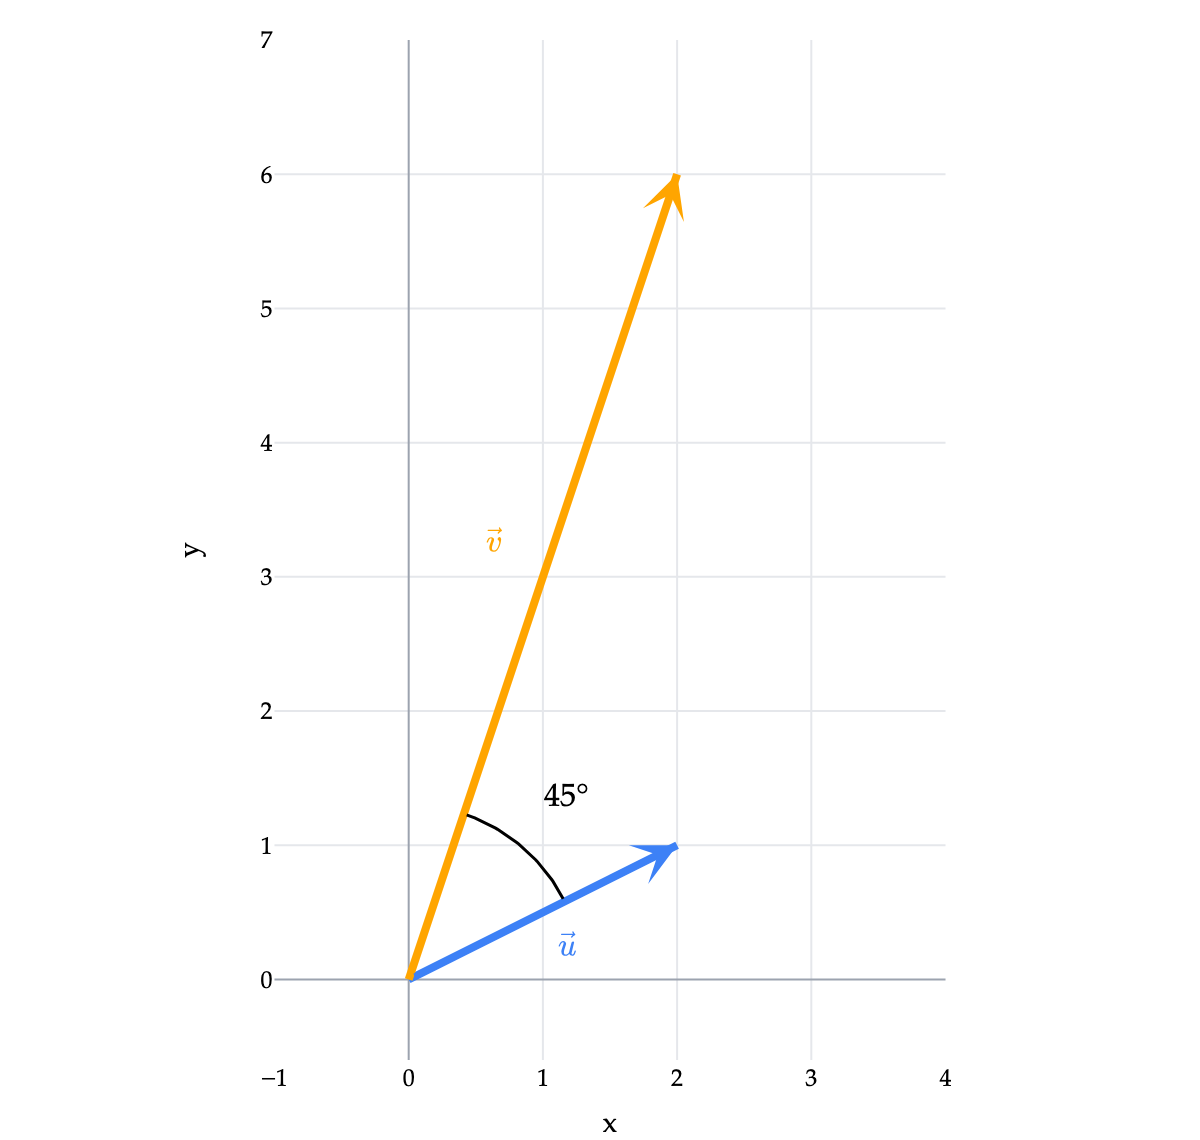

In [3]:
vectors = [((2,1),'#3d81f6',r'$\vec u$'),((2,6),'orange',r'$\vec v$')]
fig = plot_vectors(vectors)
fig.layout.annotations[1].update(x=1.2,y=0.3)
fig.layout.annotations[3].update(x=0.65,y=3.3)
fig.update_layout(width=600,height=570,xaxis_title='x',yaxis_title='y',margin=dict(l=40,r=30,t=20,b=40))
fig.update_xaxes(range=[-1,4],dtick=1,constrain='domain')
fig.update_yaxes(range=[-0.6,7],dtick=1,scaleanchor='x',scaleratio=1)
finish_vectors(fig,vectors)
arc = np.linspace(np.arctan2(1,2),np.arctan2(6,2),60)
fig.add_trace(go.Scatter(x=1.3*np.cos(arc),y=1.3*np.sin(arc),mode='lines',
    line=dict(color='black',width=1.5),showlegend=False))
mid = arc.mean()
fig.add_annotation(x=1.8*np.cos(mid),y=1.8*np.sin(mid),text='45°',showarrow=False,font=dict(color='black',size=16))
fig.show(scale=2)

### Example: An angle in three dimensions

Now, let

$$\vec w=\begin{bmatrix}5\\0\\-4\end{bmatrix},\qquad
\vec x=\begin{bmatrix}9\\1\\2\end{bmatrix}.$$

We have

$$\vec w\cdot\vec x=5(9)+0(1)+(-4)(2)=37,$$

and

$$\lVert\vec w\rVert=\sqrt{41},\qquad\lVert\vec x\rVert=\sqrt{86}.$$

So the cosine of the angle between them is

$$\boxed{\cos\theta=\frac{37}{\sqrt{41}\sqrt{86}}}.$$

This is an exact answer. If we wanted the angle in degrees, we could use a calculator in degree mode:

$$\theta=\cos^{-1}\left(\frac{37}{\sqrt{41}\sqrt{86}}\right)\approx51.5^\circ.$$

The positive dot product tells us the angle should be less than $90^\circ$, which is a useful check.

::::{tip} Activity 3
Let $\vec a=\begin{bmatrix}1\\2\\2\end{bmatrix}$ and $\vec b=\begin{bmatrix}2\\1\\-2\end{bmatrix}$.

1. Find the cosine of the angle between $\vec a$ and $\vec b$. What is the angle?
2. Find the cosine of the angle between $\vec a$ and $\vec a+\vec b$.
3. Find the cosine of the angle between $\vec a$ and $-\vec a$. What is the angle?

:::{tip} Solution
:class: dropdown

1. $\vec a\cdot\vec b=2+2-4=0$ and both norms are 3, so $\cos\theta=0$ and $\theta=90^\circ$.
2. $\vec a+\vec b=\begin{bmatrix}3\\3\\0\end{bmatrix}$, with norm $\sqrt{18}$. Since $\vec a\cdot(\vec a+\vec b)=3+6+0=9$, the cosine is $\frac{9}{3\sqrt{18}}=\frac{1}{\sqrt{2}}$.
3. $\vec a\cdot(-\vec a)=-9$, so the cosine is $\frac{-9}{3(3)}=-1$ and the angle is $180^\circ$.
:::
::::

### How large can a dot product be?

Since $-1\leq\cos\theta\leq1$, the geometric formula tells us that

$$-\lVert\vec u\rVert\lVert\vec v\rVert\leq\vec u\cdot\vec v
\leq\lVert\vec u\rVert\lVert\vec v\rVert.$$

Equivalently, $|\vec u\cdot\vec v|\leq\lVert\vec u\rVert\lVert\vec v\rVert$. This is called the **Cauchy–Schwarz inequality**. It also holds if either vector is zero, since both sides are then zero.

For example, if $\lVert\vec u\rVert=5$ and $\lVert\vec v\rVert=12$, their dot product must be between $-60$ and $60$. It is 60 when they point in the same direction, and $-60$ when they point in opposite directions.

---

## Application: Work done by a force

Suppose you pull an object along a straight track. A force pointing along the track helps move it forward; a force perpendicular to the track does no work along that displacement.

For a **constant force** $\vec F$ acting while an object undergoes displacement $\vec d$, the **work** done by that force is

$$W=\vec F\cdot\vec d=\lVert\vec F\rVert\lVert\vec d\rVert\cos\theta.$$

If force is measured in newtons and displacement in meters, work is measured in **joules**.

For example, suppose $\vec F=\begin{bmatrix}3\\4\end{bmatrix}$ newtons and the object moves $\vec d=\begin{bmatrix}2\\0\end{bmatrix}$ meters along a horizontal track. Then

$$W=3(2)+4(0)=\boxed{6\text{ joules}}.$$

The vertical component of this force contributes no work because there is no vertical displacement.

::::{tip} Activity 4
An object moves through displacement $\vec d=\begin{bmatrix}3\\4\end{bmatrix}$ meters. Compute the work done by each constant force, considered separately:

1. $\vec F_1=\begin{bmatrix}6\\8\end{bmatrix}$ newtons.
2. $\vec F_2=\begin{bmatrix}-4\\3\end{bmatrix}$ newtons.
3. $\vec F_3=\begin{bmatrix}-3\\-4\end{bmatrix}$ newtons.

For each one, explain how the sign of the work relates to the force's direction relative to the displacement.

:::{tip} Solution
:class: dropdown

1. $W_1=6(3)+8(4)=50$ joules. The force points in the same direction as the displacement, so it does positive work.
2. $W_2=-4(3)+3(4)=0$ joules. The force is perpendicular to the displacement.
3. $W_3=-3(3)-4(4)=-25$ joules. The force points opposite to the displacement, so it does negative work.
:::
::::